In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
df = pd.read_csv(r"C:\Users\hp\OneDrive - Teesside University\Masters project\heart.csv")

In [4]:
df.head()
#To get fisrt 5 rows

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df.tail()
#prints the last 5 rows

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [6]:
df.info()
#prints information about the DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


Information of attributes in the dataset 
1.	age	: Age of person in years
2.	sex	: 0 represent female, while 1 is for Male
3.	cp	: The type of chest pain in individuals.
4.	trestbps :	The resting blood pressure in patients (mm Hg)
5.	chol	 : The level of serum cholesterol in mg/dl
6.	fbs	: The value of fasting blood sugar 0 for true and 1 for false
7.	restecg	 : The result of resting electrocardiographic with 0,1,2 values 
8.	restecg	 : The maximum rate of heart obtained
9.	exang	 : Exercise, 1 implies Yes , 0 for No
10.	oldpeak	 : State of order
11.	slope	 : Exercise-induced ST depression in comparison to rest
12.	ca  : main vessels (0–3), each coloured differently with fluoroscopy
13.	thal	 : 0 denotes normal life, 1 a defect fixed, and 2 a defect reversible.
14.	target	 : 0 points to no heart disease, 1 represents having illness


In [7]:
# Statical measures of data such as min, max, count avg and percentile details of each columns

df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
# Checking for null valuses in dataset

df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
df.info()
print()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB



(1025, 14)

In [10]:
# Checking for duplicated values in dataset

df.duplicated().sum()

723

In [11]:
#Removing the duplicate datas in the dataset

df.drop_duplicates()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


In [12]:
df.shape

(1025, 14)

In [13]:
#Print the distribution of target variable
df['target'].value_counts()

1    526
0    499
Name: target, dtype: int64

# Exploratory data analysis

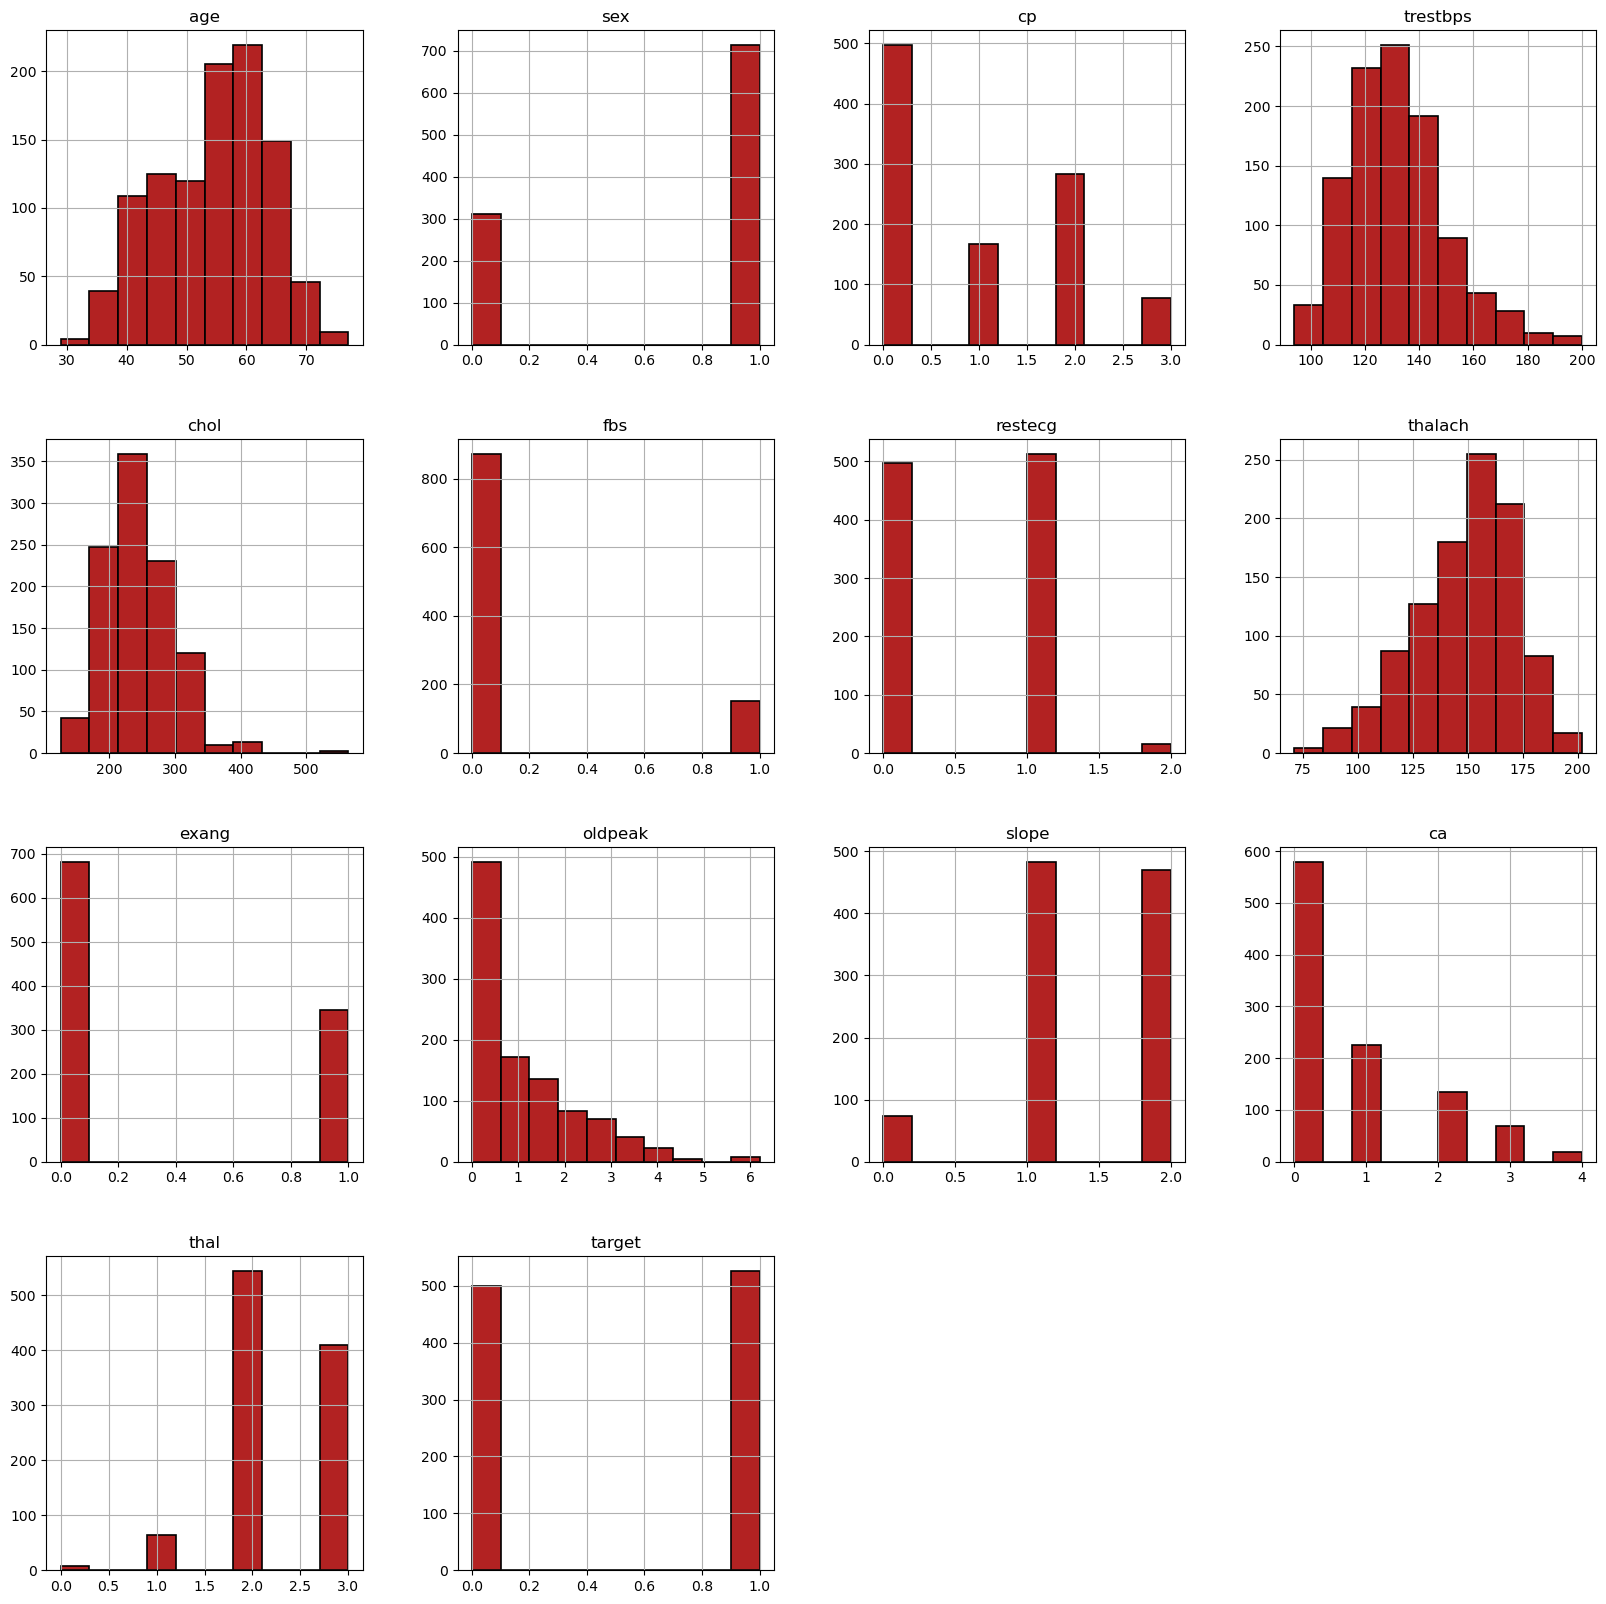

In [14]:
df.hist(edgecolor="black", linewidth=1.2, color=['firebrick'], figsize=(20, 20))
plt.show()

In [15]:
import seaborn as sns

<AxesSubplot:xlabel='target', ylabel='count'>

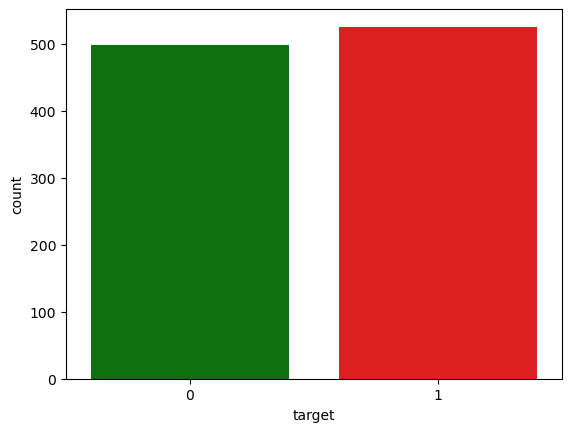

In [16]:
plt.figure(dpi=100)

colors = ["green", "red"]
sns.set_palette(colors)
sns.countplot(x=df['target'])

0 - NOT having heart Disease
1 - Having the Risk of Heart Disease

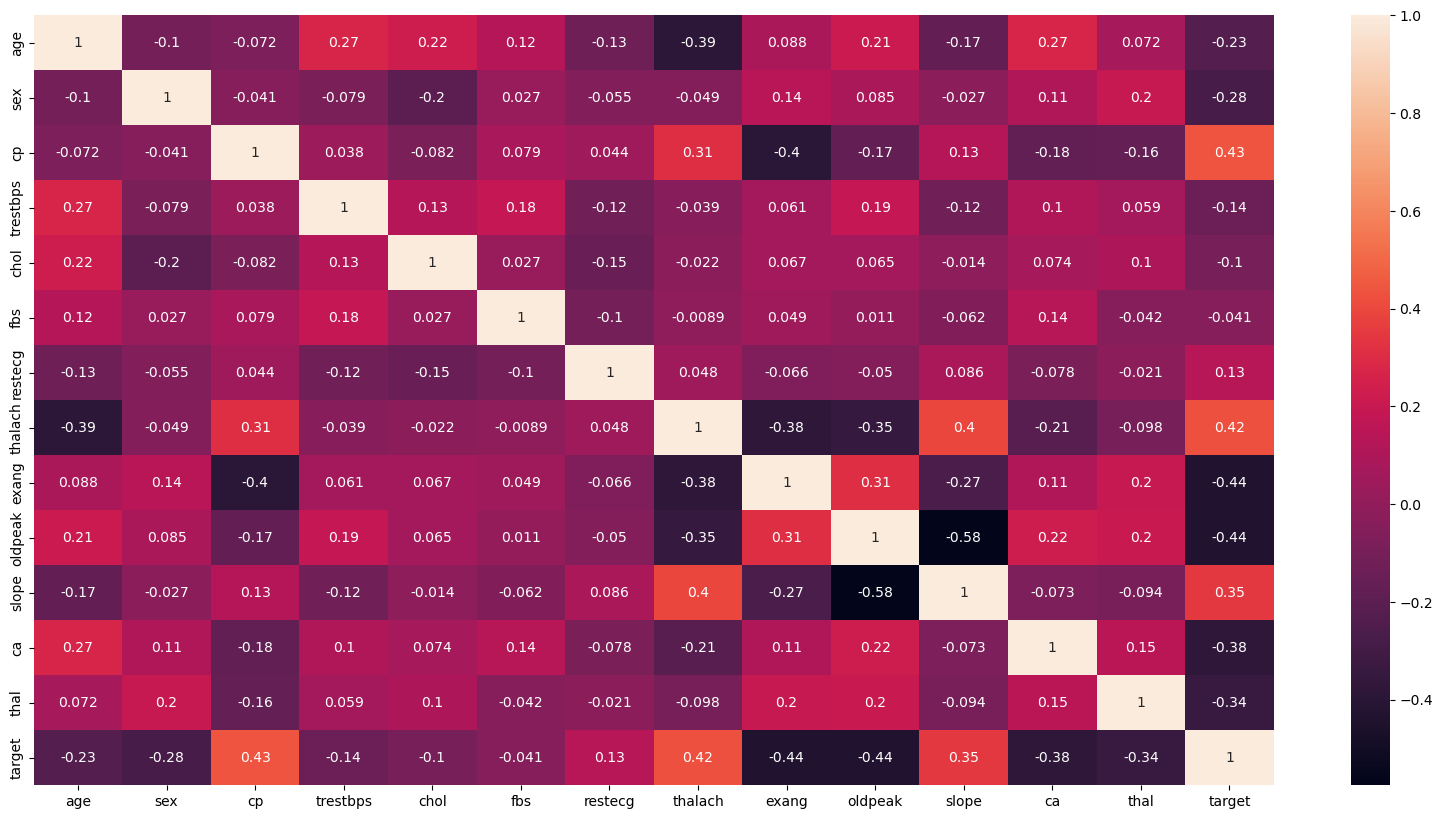

In [17]:
# visualizing correlation matrix
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [19]:
y = df['target']
X = df.drop(columns='target', axis=1)


In [20]:
print(X)

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  
0         2   2     3  
1         0   0     3  
2  

In [21]:
print(y)

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64


spitting the data into train and test data

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Logistic Regression 

In [25]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

In [26]:
LRModel = LogisticRegression()
LRModel.fit(X_train,y_train)
pred_lr = LRModel.predict(X_test)
print("Classification Report : Logistic Regression \n")
print(classification_report(y_test,pred_lr))

Classification Report : Logistic Regression 

              precision    recall  f1-score   support

           0       0.88      0.75      0.81       159
           1       0.77      0.89      0.83       149

    accuracy                           0.82       308
   macro avg       0.83      0.82      0.82       308
weighted avg       0.83      0.82      0.82       308



In [27]:
confusion_matrix(y_test, pred_lr)

array([[119,  40],
       [ 16, 133]], dtype=int64)

# Random forest Classifier

In [28]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=5)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [29]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.83      0.89       159
           1       0.84      0.95      0.89       149

    accuracy                           0.89       308
   macro avg       0.89      0.89      0.89       308
weighted avg       0.90      0.89      0.89       308



In [30]:
confusion_matrix(y_test, pred_rf)

array([[132,  27],
       [  7, 142]], dtype=int64)

# DecisionTreeClassifier

In [31]:
from sklearn.tree import DecisionTreeClassifier

In [32]:
tree= DecisionTreeClassifier(criterion= 'gini', max_depth =20, max_features='sqrt', 
                             min_samples_leaf= 4,min_samples_split=10, random_state=None, splitter='random')
tree.fit(X_train, y_train)
pred_DTC = tree.predict(X_test)

In [33]:
print(classification_report(y_test, pred_DTC))

              precision    recall  f1-score   support

           0       0.81      0.84      0.83       159
           1       0.83      0.79      0.81       149

    accuracy                           0.82       308
   macro avg       0.82      0.82      0.82       308
weighted avg       0.82      0.82      0.82       308



In [34]:
confusion_matrix(y_test, pred_DTC)

array([[134,  25],
       [ 31, 118]], dtype=int64)

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy_score(y_test, pred_DTC)


0.8181818181818182

# Support vector machine SVM

In [36]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
svc = SVC()
parameters = {'kernel':('linear', 'rbf'), 'C':[1, 10]}  #Parameters to try in GridSearch
svc_classifier = GridSearchCV(svc, parameters)
svc_classifier.fit(X_train, y_train)
svc_classifier.best_params_

{'C': 1, 'kernel': 'linear'}

In [37]:
from sklearn.metrics import classification_report,plot_confusion_matrix 
from sklearn.metrics import accuracy_score

svc = SVC() 
svc.fit(X_train,y_train)
pred_svc = svc.predict(X_test)
print(classification_report(y_test,pred_svc))

              precision    recall  f1-score   support

           0       0.71      0.63      0.67       159
           1       0.65      0.72      0.68       149

    accuracy                           0.68       308
   macro avg       0.68      0.68      0.68       308
weighted avg       0.68      0.68      0.67       308



# Naive Bayes Classifier

In [38]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
print("Traiing Score is: {}".format(nb.score(X_train, y_train) * 100))
pred_nbc = nb.predict(X_test)
am_nb = accuracy_score(y_test, pred_nbc) * 100
print("Accuracy of Naive Bayes Classifier is: {}%".format(am_nb))
print("Confusion Matrix of Naive Bayes Classifier is: \n{}".format(confusion_matrix(y_test, pred_nbc)))
print("{}".format(classification_report(y_test, pred_nbc)))

Traiing Score is: 85.21617852161785
Accuracy of Naive Bayes Classifier is: 81.4935064935065%
Confusion Matrix of Naive Bayes Classifier is: 
[[118  41]
 [ 16 133]]
              precision    recall  f1-score   support

           0       0.88      0.74      0.81       159
           1       0.76      0.89      0.82       149

    accuracy                           0.81       308
   macro avg       0.82      0.82      0.81       308
weighted avg       0.82      0.81      0.81       308



 By comparing the performance accuracy of five machine learning models,
 It is fornd that the RANDOM FOREST CLASSIFIER has the highest accuracy with 89% 
 trying steps to increase the test accuracy of the RF classifier


feature scaling is done on the model to boost the accuracy score

In [39]:
print("Accuracy score before feature scaling")
print("Train Accuracy :", accuracy_score(y_train, rf.predict(X_train)))
print("Test Accuracy :", accuracy_score(y_test, rf.predict(X_test)))

Accuracy score before feature scaling
Train Accuracy : 0.9483960948396095
Test Accuracy : 0.8896103896103896


In [40]:
#feature scaling
scaler= StandardScaler()
x_train_scaler= scaler.fit_transform(X_train)
x_test_scaler= scaler.fit_transform(X_test)

In [41]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=5)
rf.fit(x_train_scaler, y_train)
pred_rf_scaler= rf.predict(x_test_scaler)

In [42]:
print(classification_report(y_test, pred_rf_scaler))

              precision    recall  f1-score   support

           0       0.94      0.81      0.87       159
           1       0.82      0.95      0.88       149

    accuracy                           0.87       308
   macro avg       0.88      0.88      0.87       308
weighted avg       0.88      0.87      0.87       308



In [43]:
print("Accuracy score After feature scaling")
print("Train Accuracy :", accuracy_score(y_train, rf.predict(x_train_scaler)))
print("Test Accuracy :", accuracy_score(y_test, rf.predict(x_test_scaler)))

Accuracy score After feature scaling
Train Accuracy : 0.9470013947001394
Test Accuracy : 0.8733766233766234


The test Accuracy is reduced by appling feature scaling

Applying K-Fold cross validation to improove performance of Random forest classifier.

In [44]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=5)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [45]:
print("Accuracy score Before K-Fold cross validation")
print("Train Accuracy :", accuracy_score(y_train, rf.predict(X_train)))
print("Test Accuracy :", accuracy_score(y_test, rf.predict(X_test)))

Accuracy score Before K-Fold cross validation
Train Accuracy : 0.9511854951185496
Test Accuracy : 0.8961038961038961


In [46]:
#applying k-fold crossvalidation technique

params = {
    'max_depth': [1, 2, 5, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'max_features': [2,3,4],
    'n_estimators': [10, 30, 50, 100, 200]
}

In [47]:
classifier_rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(estimator=classifier_rf, param_grid=params, 
                          cv=4, n_jobs=-1, verbose=1, scoring = "accuracy")
grid_search.fit(X,y)

Fitting 4 folds for each of 375 candidates, totalling 1500 fits


GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [1, 2, 5, 10, 20],
                         'max_features': [2, 3, 4],
                         'min_samples_leaf': [5, 10, 20, 50, 100],
                         'n_estimators': [10, 30, 50, 100, 200]},
             scoring='accuracy', verbose=1)

In [48]:
rf_imp = grid_search.best_estimator_

rf_imp.fit(X_train, y_train)
pred_rf_imp = rf_imp.predict(X_test)

print(classification_report(y_test, rf_imp.predict(X_test)))

              precision    recall  f1-score   support

           0       0.95      0.90      0.93       159
           1       0.90      0.95      0.93       149

    accuracy                           0.93       308
   macro avg       0.93      0.93      0.93       308
weighted avg       0.93      0.93      0.93       308



In [49]:
print("Train Accuracy :", accuracy_score(y_train, rf_imp.predict(X_train)))
print("Train Confusion Matrix:")
print(confusion_matrix(y_train, rf_imp.predict(X_train)))

Train Accuracy : 0.9707112970711297
Train Confusion Matrix:
[[327  13]
 [  8 369]]


In [50]:
print("Test Accuracy :", accuracy_score(y_test, rf_imp.predict(X_test)))
print("Test Confusion Matrix:")
print(confusion_matrix(y_test, rf_imp.predict(X_test)))

Test Accuracy : 0.9253246753246753
Test Confusion Matrix:
[[143  16]
 [  7 142]]


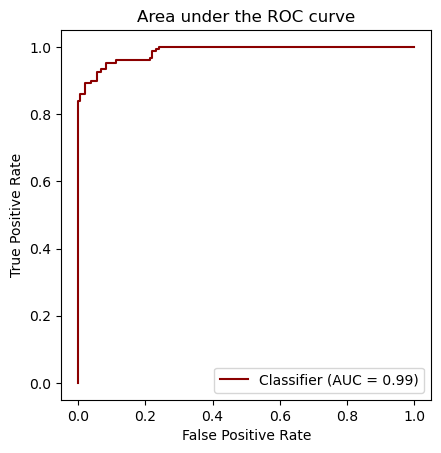

In [51]:
# Plot Area under the curve for RF model
rf_imp_predict = rf_imp.predict(X_test)
rf_imp_predict_proba = rf_imp.predict_proba(X_test)
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    rf_imp_predict_proba[:, 1],
    color="darkred")
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Area under the ROC curve")
plt.legend()
plt.show()

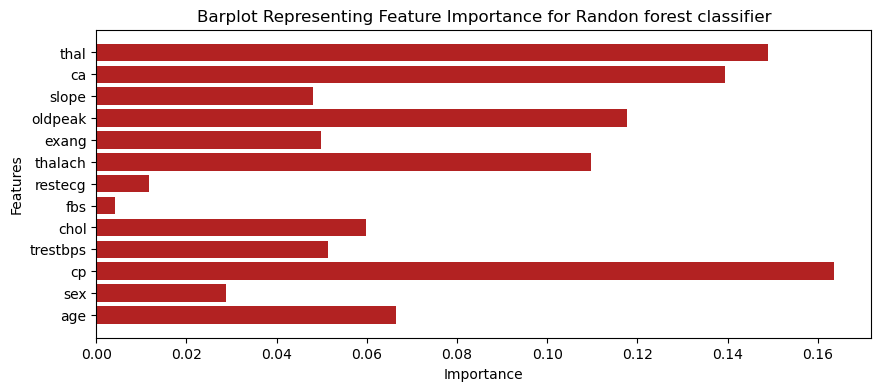

In [52]:

imp_feature_rf = pd.DataFrame({'Feature': ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
                                          'exang', 'oldpeak', 'slope', 'ca', 'thal'],
                               'Importance': rf_imp.feature_importances_})


plt.figure(figsize=(10, 4))
plt.title("Barplot Representing Feature Importance for Randon forest classifier")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.barh(imp_feature_rf['Feature'], imp_feature_rf['Importance'], color=['firebrick'])
plt.show()

## saving the best peroformanced model for the web application 

In [53]:
# Creating a pickle file for the RFC
import pickle

filename = 'rfc-model.pkl'
pickle.dump(rf_imp, open(filename, 'wb'))

In [54]:
load_rfmodel = pickle.load(open('rfc-model.pkl', 'rb'))

In [55]:
load_rfmodel.predict(X_test)

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1,